# Step 7 (RQ3) — far-OOD Gaussian + OOD consolidation  (Kaggle)

Re-evaluates the Step-6 winner (**parallel** placement, both heads) across the
full OOD list — far (SVHN, **Gaussian noise [new]**) + near (CIFAR100-clean,
TinyImageNet) — and consolidates the RQ3 table.

**Kaggle setup:** GPU T4 + Internet ON; **+ Add Input → bpeft-data** (CIFAR-100 +
SVHN); TinyImageNet downloads at runtime. Run top to bottom (~15–30 min; parallel
is cheap, no Full-FT). Results in `/kaggle/working/thesis/results` → **Save Version**.

## 0. GPU + environment check

In [1]:
import torch, sys
print('python:', sys.version.split()[0], '| torch:', torch.__version__)
print('cuda  :', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
assert torch.cuda.is_available(), 'Enable GPU: Settings > Accelerator > GPU T4'

python: 3.12.13 | torch: 2.10.0+cu128
cuda  : True | Tesla T4


## 1. Clone the repo + install deps

In [2]:
import os, subprocess
REPO_URL = 'https://github.com/notAvailable73/thesis.git'
BRANCH   = 'main'                      # <-- branch with the Step 7 commit
REPO_DIR = '/kaggle/working/thesis'
if not os.path.isdir(os.path.join(REPO_DIR, '.git')):
    subprocess.run(['git', 'clone', '--branch', BRANCH, REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(['git', '-C', REPO_DIR, 'fetch', 'origin', BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'reset', '--hard', f'origin/{BRANCH}'], check=True)
os.chdir(REPO_DIR)
print('cwd:', os.getcwd())
print(subprocess.run(['git', 'log', '--oneline', '-1'], capture_output=True, text=True).stdout.strip())
!pip -q install -r requirements.txt
assert os.path.exists('src/datasets/gaussian_noise_ood.py'), \
    'MISSING gaussian_noise_ood.py — push the Step 7 commit to this BRANCH.'
print('Step 7 code present — good.')

Cloning into '/kaggle/working/thesis'...


cwd: /kaggle/working/thesis
571078c Merge pull request #6 from notAvailable73/Step-6-1X1-CONV
Step 7 code present — good.


## 2. Stage data from the attached Kaggle Dataset (bpeft-data)

Resilient: accepts the CIFAR-100 tarball OR the (possibly nested) extracted folder.

In [3]:
import os, shutil, hashlib, glob
os.makedirs('data/svhn', exist_ok=True)
CIFAR_MD5 = 'eb9058c3a382ffc7106e4002c42a8d85'

def _find_file(name):
    hits = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    return hits[0] if hits else None

def _find_cifar_root():
    for meta in glob.glob('/kaggle/input/**/meta', recursive=True):
        d = os.path.dirname(meta)
        if os.path.exists(os.path.join(d, 'train')) and os.path.exists(os.path.join(d, 'test')):
            return d
    return None

if os.path.isdir('data/cifar-100-python') or \
   (os.path.exists('data/cifar-100-python.tar.gz') and os.path.getsize('data/cifar-100-python.tar.gz') > 0):
    print('[cifar] already staged')
else:
    tar = _find_file('cifar-100-python.tar.gz'); root = _find_cifar_root()
    if tar:
        shutil.copy(tar, 'data/cifar-100-python.tar.gz')
        assert hashlib.md5(open('data/cifar-100-python.tar.gz','rb').read()).hexdigest() == CIFAR_MD5
        print('[cifar] staged tarball (md5 OK)')
    elif root:
        shutil.copytree(root, 'data/cifar-100-python')
        print(f'[cifar] copied extracted files from {root}')
    else:
        raise AssertionError('CIFAR-100 not found under /kaggle/input — attach bpeft-data (+ Add Input).')

dst = 'data/svhn/test_32x32.mat'
if not (os.path.exists(dst) and os.path.getsize(dst) > 0):
    src = _find_file('test_32x32.mat'); assert src, 'test_32x32.mat not found under /kaggle/input'
    shutil.copy(src, dst); print(f'[svhn] staged ({os.path.getsize(dst)/1e6:.0f} MB)')
else:
    print('[svhn] already present')

tin = _find_file('tiny-imagenet-200.zip')
if tin: shutil.copy(tin, 'data/tiny-imagenet-200.zip'); print('[tin] staged from dataset')
else:   print('[tin] not in dataset — downloads at runtime (Internet ON)')

[cifar] copied extracted files from /kaggle/input/datasets/hamimsaadalraji/bpeft-data/cifar-100-python/cifar-100-python
[svhn] staged (64 MB)
[tin] not in dataset — downloads at runtime (Internet ON)


## 3. Build the frozen CIFAR-FS split

In [4]:
!python scripts/build_cifar_fs_split.py
import json
sp = json.load(open('data/cifar_fs_split.json'))
print('split status:', sp.get('_status'), '| sizes:', {k: len(v) for k, v in sp.items() if isinstance(v, list)})
assert sp.get('_status') != 'synthetic_fallback', 'split is the SYNTHETIC fallback — fix before running'

wrote /kaggle/working/thesis/data/cifar_fs_split.json  (64/16/20, disjoint, union=100, status=canonical_bertinetto_via_torchmeta)
split status: canonical_bertinetto_via_torchmeta | sizes: {'train': 64, 'val': 16, 'test': 20}


## 4. (optional) Tests

In [5]:
!python -u -m pytest -q tests/test_gaussian_ood.py
# full suite: !python -u -m pytest -q

....                                                                     [100%]
4 passed in 4.13s


## 5. Re-eval the parallel winner with the extended OOD list

train + eval for parallel × {evidential, softmax} with --use-tinyimagenet
--use-gaussian. svhn/cifar100/tin reproduce Step 6; gaussian_far is new.
Resumable (skips finished phase4 JSONs).

In [6]:
import subprocess, os
NUM_EPISODES = 600
RUNS = ['exp_phase3_placement_parallel_evidential',
        'exp_phase3_placement_parallel_softmax']
def head_desc(name):
    return 'prototype-evidential' if name.endswith('evidential') else 'prototype-softmax'
def result_path(name):
    return f'results/phase4_parallel_bottleneck_{head_desc(name)}_metrics.json'
def run(cmd):
    print('>>>', ' '.join(cmd), flush=True); return subprocess.run(cmd).returncode
status = {}
for name in RUNS:
    out = result_path(name)
    if os.path.exists(out):
        print(f'== SKIP {name} (found {out}) =='); status[name] = 'skip (exists)'; continue
    print(f'\n{"="*72}\n== {name} ==\n{"="*72}', flush=True)
    cfg = f'configs/{name}.yaml'
    rc = run(['python', 'scripts/train.py', '--config', cfg, '--wandb-mode', 'disabled'])
    if rc != 0: status[name] = f'TRAIN failed (rc={rc})'; continue
    rc = run(['python', 'scripts/evaluate.py', '--config', cfg,
              '--num-episodes', str(NUM_EPISODES), '--wandb-mode', 'disabled',
              '--results-suffix', 'phase4_parallel', '--use-tinyimagenet', '--use-gaussian'])
    status[name] = 'OK' if (rc == 0 and os.path.exists(out)) else f'EVAL failed (rc={rc})'
print('\nRUN STATUS')
for name in RUNS: print(f'  {name:46s} {status.get(name, "not run")}')


== exp_phase3_placement_parallel_evidential ==
>>> python scripts/train.py --config configs/exp_phase3_placement_parallel_evidential.yaml --wandb-mode disabled
[05:09:58] INFO bpeft.train: config: configs/exp_phase3_placement_parallel_evidential.yaml  seed: 42  trainer.type: episodic
[05:09:58] INFO bpeft.train: wandb: disabled (no-op logger)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s] 


[05:10:01] INFO bpeft.train: trainable params: 31,746
[05:11:04] INFO bpeft.train: epoch   1/30  train_loss=0.3836  train_acc=0.885  val_loss=0.4983  val_acc=0.850  kl_w=0.010  mean_ev=1.7873  grad_norm=0.5525  global_step=100
[05:12:04] INFO bpeft.train: epoch   2/30  train_loss=0.3492  train_acc=0.885  val_loss=0.4988  val_acc=0.847  kl_w=0.020  mean_ev=1.8908  grad_norm=0.6008  global_step=200
[05:13:06] INFO bpeft.train: epoch   3/30  train_loss=0.3285  train_acc=0.895  val_loss=0.5945  val_acc=0.847  kl_w=0.030  mean_ev=2.0667  grad_norm=0.6845  global_step=300
[05:14:08] INFO bpeft.train: epoch   4/30  train_loss=0.3301  train_acc=0.892  val_loss=0.4810  val_acc=0.841  kl_w=0.040  mean_ev=2.1410  grad_norm=0.7911  global_step=400
[05:15:11] INFO bpeft.train: epoch   5/30  train_loss=0.3130  train_acc=0.900  val_loss=0.4399  val_acc=0.851  kl_w=0.050  mean_ev=2.1424  grad_norm=0.7247  global_step=500
[05:16:14] INFO bpeft.train: epoch   6/30  train_loss=0.3343  train_acc=0.892  va

## 6. Consolidate the RQ3 OOD table + plot

saved /kaggle/working/thesis/results/phase4_ood_table.json
saved /kaggle/working/thesis/results/step7_ood_comparison.png
{
  "config": "exp_phase3_placement_parallel",
  "heads": {
    "evidential": {
      "cifar100": {
        "auroc": 0.9119,
        "fpr_at_95": 0.3929
      },
      "gaussian": {
        "auroc": 0.9799,
        "fpr_at_95": 0.1306
      },
      "svhn": {
        "auroc": 0.9328,
        "fpr_at_95": 0.3795
      },
      "tinyimagenet": {
        "auroc": 0.9286,
        "fpr_at_95": 0.2956
      }
    },
    "softmax": {
      "cifar100": {
        "auroc": 0.8135,
        "fpr_at_95": 0.667
      },
      "gaussian": {
        "auroc": 0.9315,
        "fpr_at_95": 0.4246
      },
      "svhn": {
        "auroc": 0.8875,
        "fpr_at_95": 0.5187
      },
      "tinyimagenet": {
        "auroc": 0.8483,
        "fpr_at_95": 0.6065
      }
    }
  },
  "n_id": "600 episodes x 75 query",
  "n_ood": 500,
  "score_per_head": {
    "evidential": "vacuity",
    "so

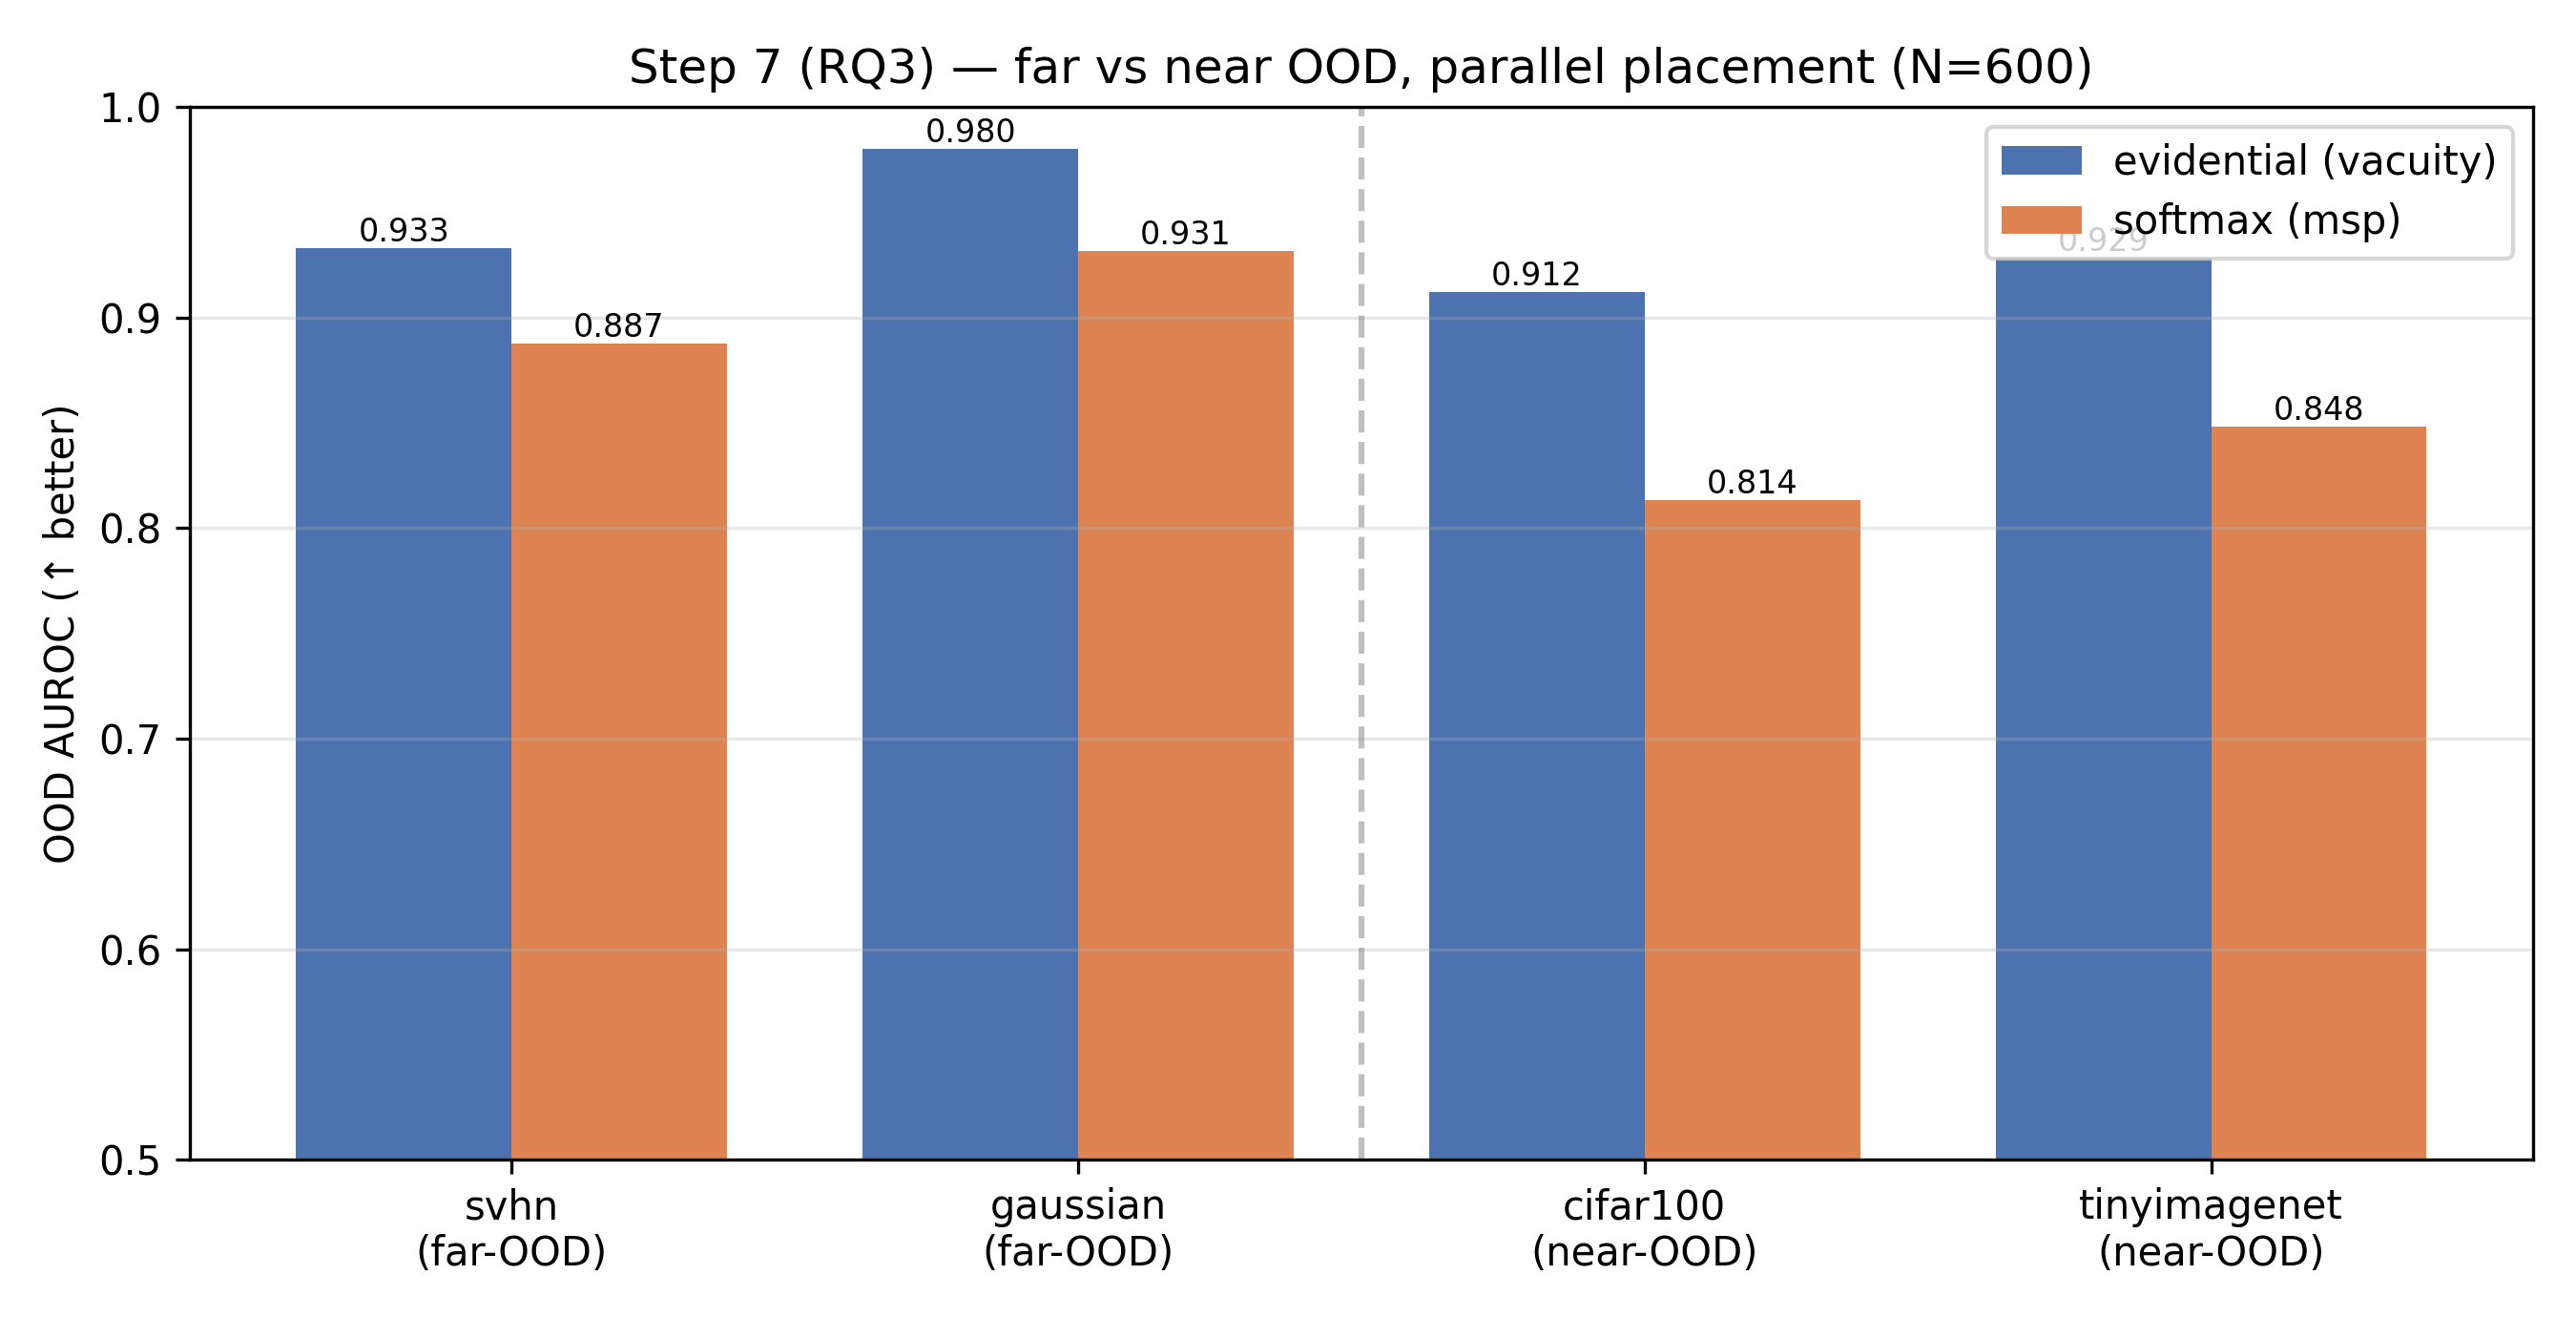

In [7]:
!python scripts/step7_ood_consolidate.py
import json
print(json.dumps(json.load(open('results/phase4_ood_table.json')), indent=2, sort_keys=True))
from IPython.display import Image
Image('results/step7_ood_comparison.png')

## 7. Persist
Results under `/kaggle/working/thesis/results`. **Save Version**, then download
`phase4_parallel_*` JSONs + `phase4_ood_table.json` + `step7_ood_comparison.png`
to commit locally.